This script computes and visualizes the quantum-derived potential energy curve 
between a pair of Argon (Ar) atoms using the Lennard-Jones (12-6) potential model.

In [4]:
# Import the necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

1. Calibration with atoms Árgon-Árgon, well known and established in the literature, to see the code works.         
Expected result for Ar-Ar interaction = -0.0104 eV

--- result of the Quantum Simulation ---
Optimal bonding distance: 3.816 Ångstroms
Energy in the fundamental state: -0.0104 eV


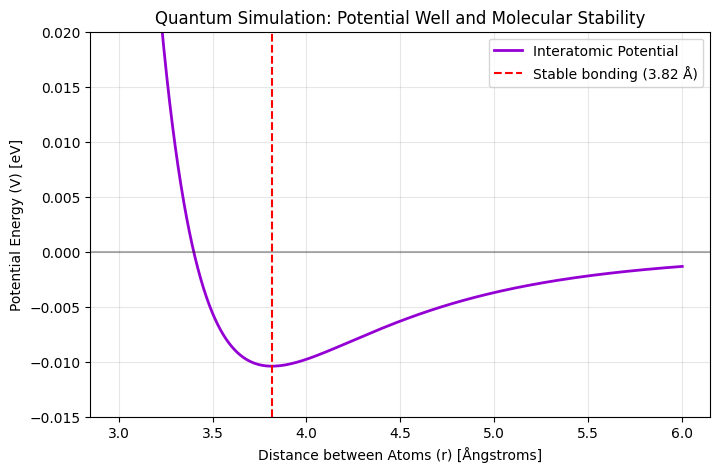

In [5]:
# Define the function for Potential Energy (Lennard-Jones)
# This equation models the quantum repulsion (Pauli) and the atraction (Van der Waals)
def molecular_quantum_energy(r, epsilon, sigma):
    """
    r:       distance between the nucleus of the atoms
    epsilon: depth of the potential well (bonding force)
    sigma:   distance where potential is zero
    """
    # Avoid division by zero if the distance is zero
    if r <= 0: return float('inf')
    
    term6 = (sigma / r) ** 6
    term12 = (sigma / r) ** 12
    
    # Classic Lennard-Jones equation
    V = 4 * epsilon * (term12 - term6)
    return V

# Define real parameters for Argon (Ar-Ar)
EPSILON = 0.0104  # in eV (electron-volt)
SIGMA = 3.40      # in Angstroms (10^-10 m)

# Quantum Optimization: Find the stable binding distance (minimum energy)
result = minimize_scalar(molecular_quantum_energy, bounds=(2.5, 6.0), args=(EPSILON, SIGMA), method='bounded')
optimal_distance = result.x
minimum_energy = result.fun

print(f"--- result of the Quantum Simulation ---")
print(f"Optimal bonding distance: {optimal_distance:.3f} Ångstroms")
print(f"Energy in the fundamental state: {minimum_energy:.4f} eV")

distances = np.linspace(3.0, 6.0, 200)
energies = [molecular_quantum_energy(r, EPSILON, SIGMA) for r in distances]

# Plots
plt.figure(figsize=(8, 5))
plt.plot(distances, energies, label='Interatomic Potential', color='darkviolet', lw=2)
plt.axvline(x=optimal_distance, color='red', linestyle='--', label=f'Stable bonding ({optimal_distance:.2f} Å)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.title('Quantum Simulation: Potential Well and Molecular Stability')
plt.xlabel('Distance between Atoms (r) [Ångstroms]')
plt.ylabel('Potential Energy (V) [eV]')
plt.ylim(-0.015, 0.02) # Ajust limits to see the well
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('lennard_jones_curve.png', dpi=300, bbox_inches='tight') # To save the plot to a .png image
plt.show()